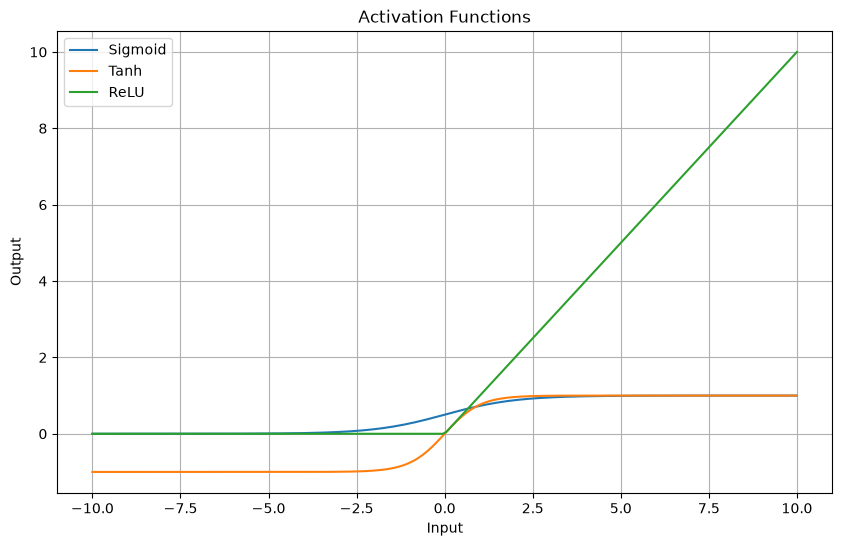

In [2]:
# ======================================================
# Part A
# Roll No: 24BAD405
# Name: Nishanth P
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Input values
x = np.linspace(-10, 10, 200)

# Activation Functions
sigmoid = tf.keras.activations.sigmoid(x)
tanh = tf.keras.activations.tanh(x)
relu = tf.keras.activations.relu(x)

# Plot
plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
# ======================================================
# Part B
# Roll No: 24BAD405
# Name: Nishanth P
# ======================================================

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0


# Function to create ANN
def create_model(activation):

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


activations = ['sigmoid', 'tanh', 'relu']

histories = {}

for act in activations:

    print(f"\nTraining using {act}")

    model = create_model(act)

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        verbose=1
    )

    histories[act] = history

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"Test Accuracy ({act}) = {acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training using sigmoid


c:\Users\nisha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8704 - loss: 0.5239 - val_accuracy: 0.9352 - val_loss: 0.2312
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9412 - loss: 0.1976 - val_accuracy: 0.9532 - val_loss: 0.1634
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9583 - loss: 0.1402 - val_accuracy: 0.9613 - val_loss: 0.1328
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9686 - loss: 0.1051 - val_accuracy: 0.9657 - val_loss: 0.1162
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0813 - val_accuracy: 0.9699 - val_loss: 0.1051
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9812 - loss: 0.0647 - val_accuracy: 0.9695 - val_loss: 0.1004
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9848 - loss: 0.0516 - val_accuracy: 0.9732 - val_loss: 0.0921
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9883 - loss: 0.0419 -

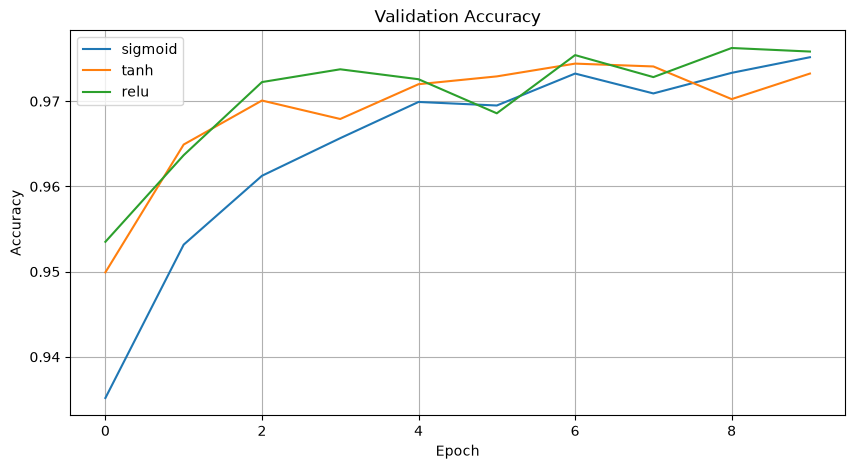

In [4]:
plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

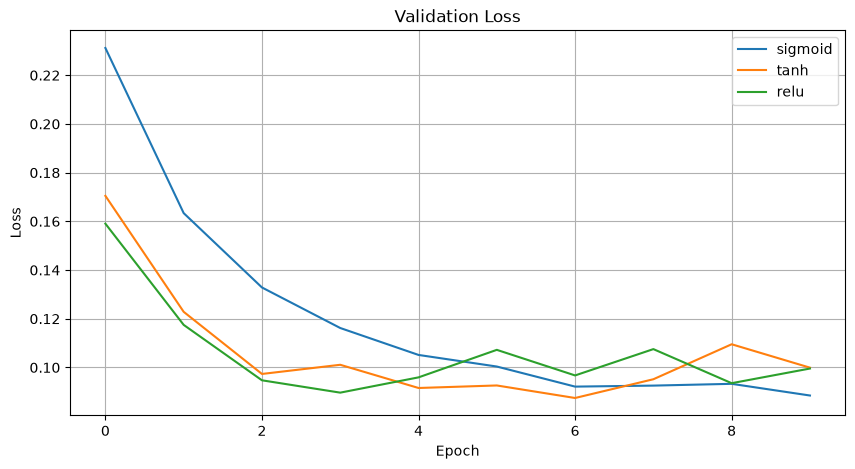

In [5]:
plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# ======================================================
# Part C
# Roll No: 24BAD405
# Name: Nishanth P
# ======================================================

from tensorflow.keras.optimizers import SGD, RMSprop, Adam

optimizers = {
    "SGD": SGD(),
    "Momentum": SGD(momentum=0.9),
    "RMSProp": RMSprop(),
    "Adam": Adam()
}

optimizer_history = {}

for name, opt in optimizers.items():

    print(f"\nTraining using {name}")

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        verbose=1
    )

    optimizer_history[name] = history

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"{name} Accuracy = {acc:.4f}")


Training using SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8236 - loss: 0.6664 - val_accuracy: 0.9074 - val_loss: 0.3284
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9092 - loss: 0.3177 - val_accuracy: 0.9240 - val_loss: 0.2667
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9248 - loss: 0.2639 - val_accuracy: 0.9320 - val_loss: 0.2356
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9349 - loss: 0.2297 - val_accuracy: 0.9423 - val_loss: 0.2077
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9421 - loss: 0.2035 - val_accuracy: 0.9480 - val_loss: 0.1922
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9474 - loss: 0.1830 - val_accuracy: 0.9521 - val_loss: 0.1740
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9525 - loss: 0.1656 - val_accuracy: 0.9551 - val_loss: 0.1610
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.95

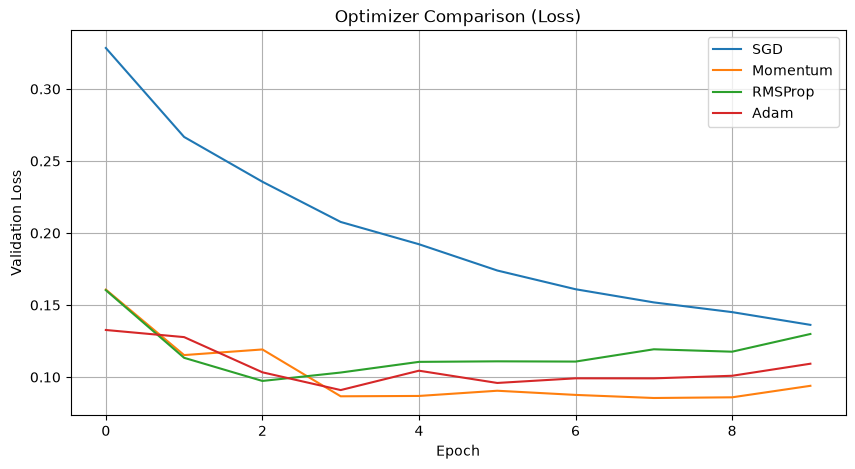

In [7]:
plt.figure(figsize=(10,5))

for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['val_loss'],
        label=name
    )

plt.title("Optimizer Comparison (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**Part D:** Google Colab [link]("https://colab.research.google.com/drive/10GK7pGbB8KSZpmRQ5SfLSITCr2rfl1wV?usp=sharing") 